In [63]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
from matplotlib.patches import Patch


# Step 0: Load Image


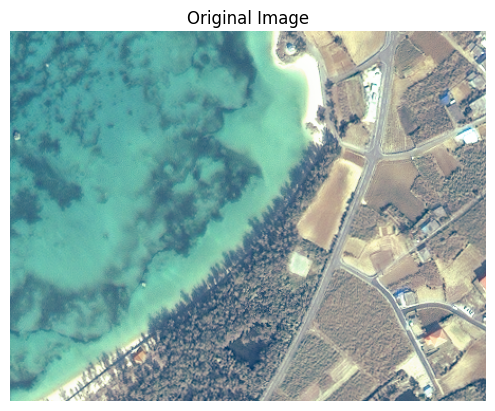

In [92]:

img = cv2.imread('irabu_zhang1.bmp')   # change filename if needed
if img is None:
    raise FileNotFoundError("Could not read 'irabu_zhang1.bmp'. Check the filename/path and run from the correct folder.")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

class_labels = {
    1: "Sea",
    2: "Tree",
    3: "Field",
    4: "Road",
    5: "Sand",
}

# Compute Mean, Covariance and Classification Functions

In [ ]:
#Step 2-4: Compute means, covariances, and classify
def compute(samples: List) -> np.ndarray:
    # Compute means and covariances
    means = {}
    covs = {}
    for k in samples:
        X = np.array(samples[k])
        N = len(X)
        mu = np.zeros(3)
        for x in X:
            mu += x
        mu = mu / N
        means[k] = mu
        
        sigma = np.zeros((3, 3))
        for x in X:
            diff = (x - mu).reshape(3, 1)
            sigma += diff @ diff.T
        sigma = sigma / (N - 1)
        sigma += np.eye(3) * 1e-6
        covs[k] = sigma

    # Classification
    result = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            x = img[i, j]
            probs = []
            for k in samples:
                mu = means[k]
                sigma = covs[k]
                inv_sigma = np.linalg.inv(sigma)
                det_sigma = np.linalg.det(sigma)
                diff = x - mu
                exponent = -0.5 * (diff.T @ inv_sigma @ diff)
                prob = np.exp(exponent) / np.sqrt(det_sigma)
                probs.append(prob)
            result[i, j] = np.argmax(probs) + 1

    return result,means,covs

def select_random_point_from_coords():
    """Select a random class and return a random point within its coordinate bounds"""
    selected_class = random.choice(range(len(class_coords)))
    x, y, width, height = class_coords[selected_class]
    
    # Generate random point within the rectangle bounds
    random_x = random.randint(x, x + width)
    random_y = random.randint(y, y + height)
    
    return {
        'class_id': selected_class + 1,
        'point': (random_x, random_y),
        'bounds': (x, y, width, height)
    }

# Training Samples (10 per class, random)

In [ ]:
# Step 1:Randomly select 10 points from each class as training data

rng = np.random.default_rng(42)  # remove/change seed for different draws each run

# [R_min, R_max), [G_min, G_max), [B_min, B_max)
# Tuned to separate tree/road/field better.
# Class order: 1-sea, 2-tree, 3-field, 4-road, 5-sand
class_ranges =  { 
    1: ((60, 86), (135, 166), (130, 156)), 
    2: ((50, 69), (90, 109), (55, 73)), 
    3: ((110, 136), (110, 136), (110, 136)), 
    4: ((135, 156), (115, 136), (85, 106)), 
    5: ((193, 211), (183, 201), (143, 161)),}

samples_1 = {}
for k, (r_rng, g_rng, b_rng) in class_ranges.items():
    r = rng.integers(r_rng[0], r_rng[1], size=10)
    g = rng.integers(g_rng[0], g_rng[1], size=10)
    b = rng.integers(b_rng[0], b_rng[1], size=10)
    samples_1[k] = np.stack([r, g, b], axis=1).tolist()

### Assign REAL-WORLD Colors

In [ ]:

result_1, means_1, covs_1 = compute(samples_1)
output_1 = np.zeros_like(img)

for k in means_1:
    color = means_1[k].astype(np.uint8)
    output_1[result_1 == k] = color
    



### Show Output in Notebook (with class labels)

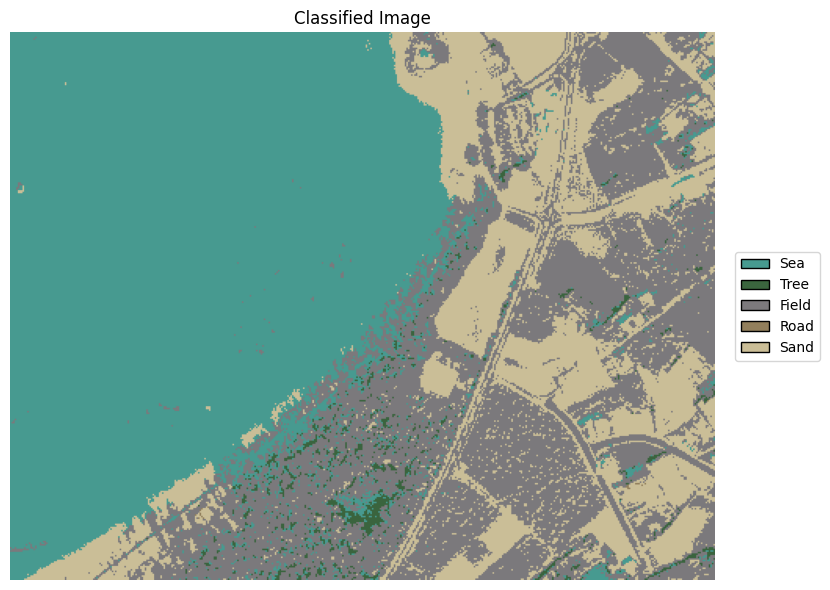

In [99]:

plt.figure(figsize=(9, 6))
plt.imshow(output_1)
plt.title("Classified Image")
plt.axis('off')

legend_handles = []
for k in sorted(means_1.keys()):
    rgb = means_1[k] / 255.0  # matplotlib expects [0,1]
    legend_handles.append(Patch(facecolor=rgb, edgecolor='black', label=class_labels[k]))

plt.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
plt.show()



# Training Samples (Click to the picture)

In [30]:
import cv2

samples_2 = {1: [], 2: [], 3: [], 4: [], 5: []}
current_class = 1

def click_event(event, x, y, flags, param):
    global current_class
    if event == cv2.EVENT_LBUTTONDOWN:
        rgb = img[y, x]
        print(f"Class {current_class}: ({x},{y}) -> {rgb}")
        samples_2[current_class].append(rgb)

        if len(samples_2[current_class]) == 10:
            print(f"✅ Class {current_class} done")
            current_class += 1

cv2.imshow("Image", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
cv2.setMouseCallback("Image", click_event)

cv2.waitKey(0)
cv2.destroyAllWindows()

print(samples_2)

Class 1: (64,197) -> [105 183 171]
Class 1: (103,51) -> [ 82 167 165]
Class 1: (160,110) -> [ 87 147 146]
Class 1: (27,211) -> [113 196 177]
Class 1: (174,137) -> [ 58 120 131]
Class 1: (231,107) -> [129 209 178]
Class 1: (45,21) -> [ 57 116 132]
Class 1: (31,146) -> [ 55 117 132]
Class 1: (39,227) -> [107 192 173]
Class 1: (193,131) -> [106 173 163]
✅ Class 1 done
Class 2: (161,330) -> [ 41  83 105]
Class 2: (172,281) -> [144 144 149]
Class 2: (229,263) -> [123 130 136]
Class 2: (258,264) -> [ 41  85 105]
Class 2: (244,223) -> [133 141 142]
Class 2: (266,178) -> [162 156 151]
Class 2: (285,134) -> [127 135 141]
Class 2: (181,283) -> [ 56  90 113]
Class 2: (292,214) -> [158 153 152]
Class 2: (161,326) -> [117 126 134]
✅ Class 2 done
Class 3: (329,299) -> [150 146 142]
Class 3: (329,299) -> [150 146 142]
Class 3: (322,261) -> [155 151 143]
Class 3: (346,291) -> [153 149 145]
Class 3: (336,244) -> [166 156 150]
Class 3: (315,271) -> [146 144 141]
Class 3: (292,309) -> [151 153 147]
Class

### Show Output in Notebook (with class labels)

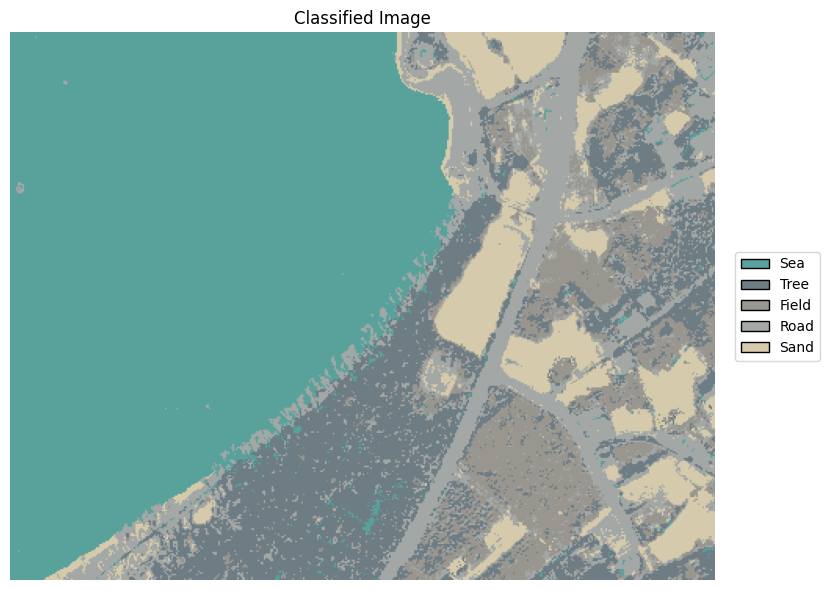

In [94]:
result_2, means_2, covs_2 = compute(samples_2)
output_2 = np.zeros_like(img)

for k in means_2:
    color = means_2[k].astype(np.uint8)
    output_2[result_2 == k] = color


plt.figure(figsize=(9, 6))
plt.imshow(output_2)
plt.title("Classified Image")
plt.axis('off')

legend_handles = []
for k in sorted(means_2.keys()):
    rgb = means_2[k] / 255.0  # matplotlib expects [0,1]
    legend_handles.append(Patch(facecolor=rgb, edgecolor='black', label=class_labels[k]))

plt.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
plt.show()



# Add class coordinates and random point selection

In [41]:
print(f"Image dimensions: height={h}, width={w}")

class_coords = [
    (130, 130, 80, 80),      # Class 1 - Upper left (water)
    (180, 250, 40, 40),     # Class 2 - Left side (coastline)
    (330, 280, 40, 40),      # Class 3 - Right centerblue
    (280, 220, 40, 40),      # Class 4 - Right lower
    (280, 150, 40, 40),        # Class 5 - Lower right (adjust if needed)
]

# Make sure coordinates fit within image bounds
class_coords = [
    (min(x, w-40), min(y, h-40), 30, 30) for x, y, width, height in class_coords
]
print("Checking coordinate bounds:")
for i, (x, y, w_coord, h_coord) in enumerate(class_coords):
    max_x = x + w_coord
    max_y = y + h_coord
    print(f"Class {i+1}: ({x},{y}) to ({max_x},{max_y})")
    

Image dimensions: height=350, width=450
Checking coordinate bounds:
Class 1: (130,130) to (160,160)
Class 2: (180,250) to (210,280)
Class 3: (330,280) to (360,310)
Class 4: (280,220) to (310,250)
Class 5: (280,150) to (310,180)


In [42]:
random_point_info = select_random_point_from_coords()
print(f"Random point selected: Class {random_point_info['class_id']}")
print(f"Point coordinates: {random_point_info['point']}")
print(f"Class bounds (x, y, width, height): {random_point_info['bounds']}")
print("\nAll class coordinates:")
for i, (x, y, w_coord, h_coord) in enumerate(class_coords):
    print(f"Class {i+1}: ({x}, {y}, {w_coord}, {h_coord})")


Random point selected: Class 5
Point coordinates: (282, 173)
Class bounds (x, y, width, height): (280, 150, 30, 30)

All class coordinates:
Class 1: (130, 130, 30, 30)
Class 2: (180, 250, 30, 30)
Class 3: (330, 280, 30, 30)
Class 4: (280, 220, 30, 30)
Class 5: (280, 150, 30, 30)


### Plot for the Selected Coordination

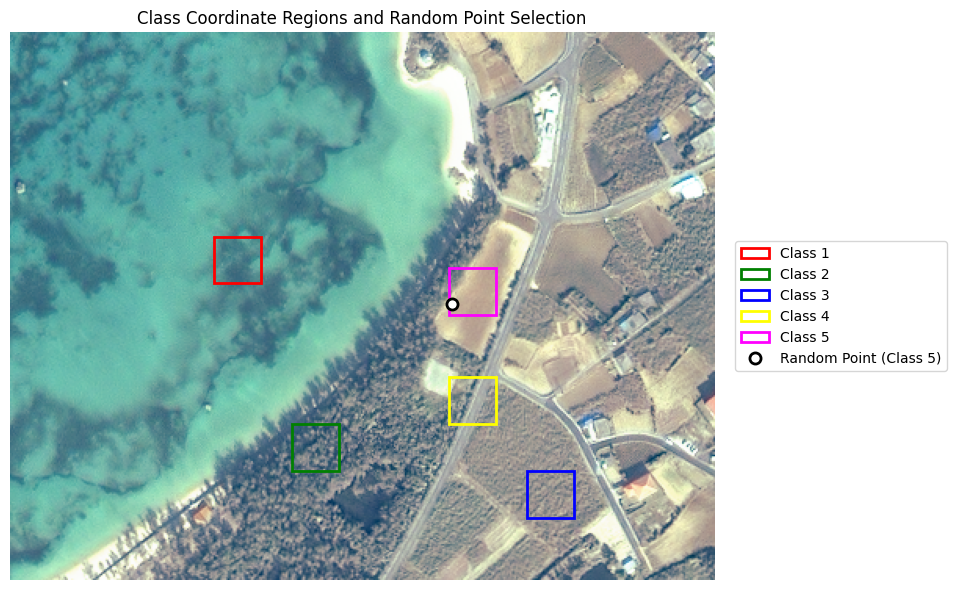

In [79]:
plt.figure(figsize=(10, 6))
plt.imshow(img)

# Draw rectangles for each class region
colors = ['red', 'green', 'blue', 'yellow', 'magenta']
for i, (x, y, w_coord, h_coord) in enumerate(class_coords):
    rect = plt.Rectangle((x, y), w_coord, h_coord, fill=False, edgecolor=colors[i], linewidth=2, label=f'Class {i+1}')
    plt.gca().add_patch(rect)

# Mark the randomly selected point
rand_x, rand_y = random_point_info['point']
plt.plot(rand_x, rand_y, 'wo', markersize=8, markeredgecolor='black', markeredgewidth=2, 
         label=f'Random Point (Class {random_point_info["class_id"]})')

plt.title("Class Coordinate Regions and Random Point Selection")
plt.axis('off')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()



In [88]:
samples_3 = {}
for class_id in range(1, 6):
    class_samples = []
    for _ in range(10):
        x, y, width, height = class_coords[class_id - 1]
        random_x = random.randint(x, x + width)
        random_y = random.randint(y, y + height)
        if 0 <= random_y < h and 0 <= random_x < w:
            rgb_value = img[random_y, random_x]
            class_samples.append(rgb_value)
    samples_3[class_id] = class_samples

### Assign REAL-WORLD Colors

In [89]:
result_3, means_3, covs_3 = compute(samples_3)
output_3 = np.zeros_like(img)
for k in means_3:
    color = means_3[k].astype(np.uint8)
    output_3[result_3 == k] = color



### Show Output in Notebook (with class labels)

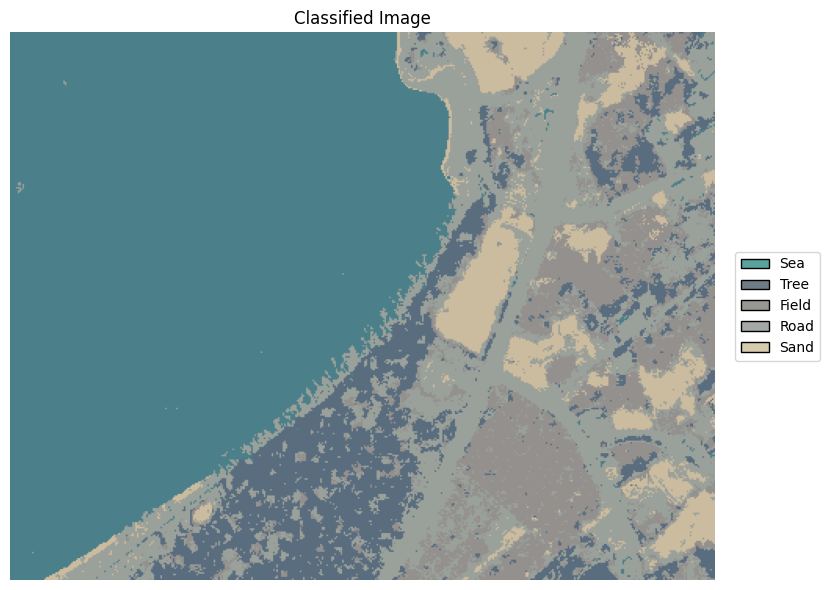

In [95]:
plt.figure(figsize=(9, 6))
plt.imshow(output_3)
plt.title("Classified Image")
plt.axis('off')

legend_handles = []
for k in sorted(means_2.keys()):
    rgb = means_2[k] / 255.0  # matplotlib expects [0,1]
    legend_handles.append(Patch(facecolor=rgb, edgecolor='black', label=class_labels[k]))

plt.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
plt.show()
